# Notebook 04 – Results Visualization and Reporting
IITB Project – Problem ID-9: Effect of Feedback on Affective and Cognitive Measures

## Goals of This Notebook
1. Load model predictions and evaluation metrics.
2. Generate visualizations for:
   - Trial-level affective state predictions
   - Feedback type comparisons
   - Participant-wise summary plots
3. Compare model performances across architectures.
4. Produce final summary tables and figures for reporting and presentations.
5. Save consolidated outputs for project documentation.

## Input Data
- model_metrics.csv → performance metrics of all models  
- predicted_vs_actual_plots/ → model prediction plots

## Output
- final_summary.csv → consolidated results per participant and feature  
- visualizations/ → plots for reports and presentations


ML Metrics:
               Model           MAE          RMSE        R2
0  LinearRegression  4.200871e-14  6.685419e-14  1.000000
1      RandomForest  1.476119e-01  4.621382e-01  0.973994 

DL Metrics:
               Model        MAE       RMSE        R2
0  BiLSTM+Attention  11.781562  20.287241 -0.038547 



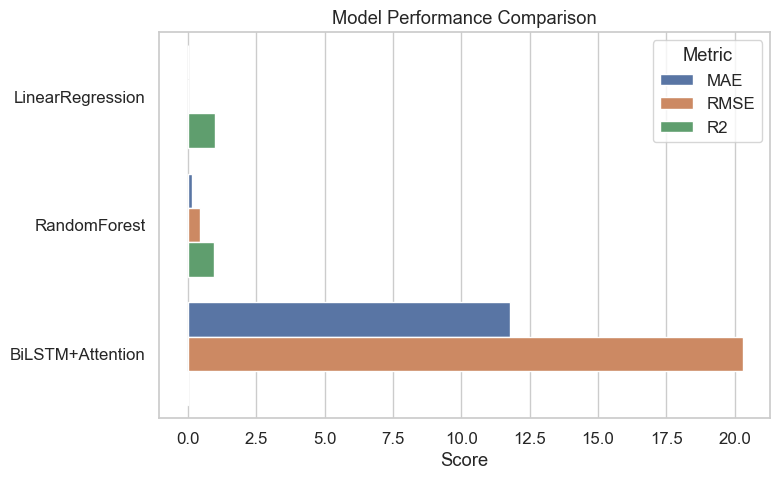


Average engagement/confusion per feedback:
     feedback  engagement  confusion
0    CORRECT   17.051485   0.651196
1  INCORRECT   20.229935   1.115852
2       SKIP   25.725677   0.990914


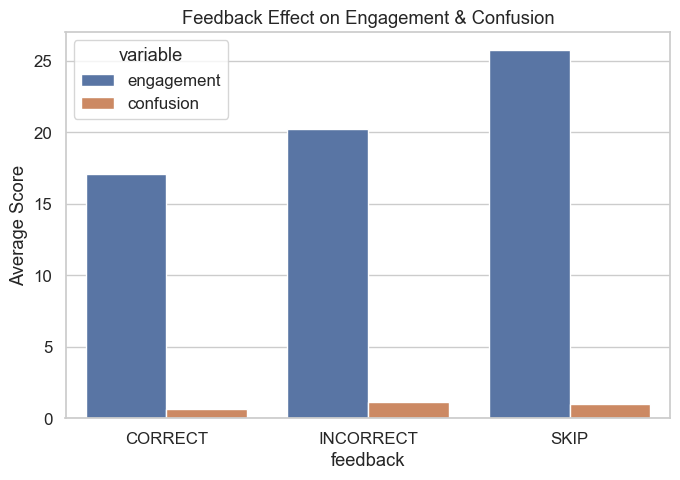

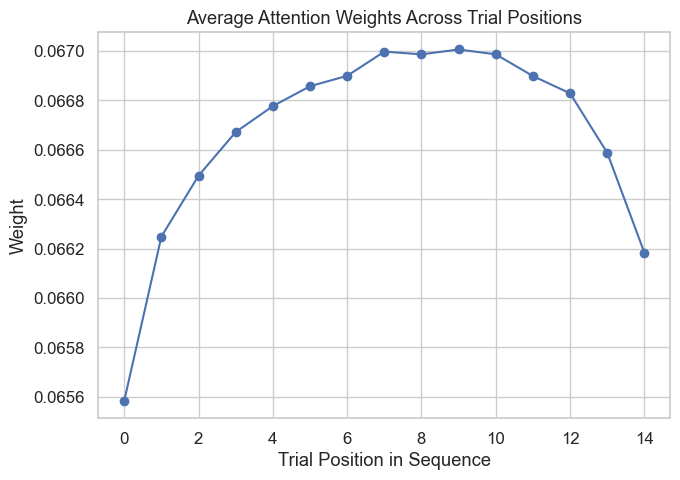

In [1]:
# ========================================
# 04_analysis_and_visualization.ipynb
# Problem ID-9: Effect of Feedback on Affective and Cognitive Measures
# ========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", font_scale=1.1)

# ================================
# Config
# ================================
RESULTS_PATH = Path("../results")
DATA_PATH = Path("../results/preprocessed_features.csv")

# ================================
# Step 1: Load Metrics
# ================================
ml_metrics = pd.read_csv(RESULTS_PATH / "ml_baseline_metrics.csv")
dl_metrics = pd.read_csv(RESULTS_PATH / "dl_metrics.csv")

print("ML Metrics:\n", ml_metrics, "\n")
print("DL Metrics:\n", dl_metrics, "\n")

all_metrics = pd.concat([ml_metrics, dl_metrics], ignore_index=True)

# 🔹 Plot metrics comparison
plt.figure(figsize=(8,5))
sns.barplot(data=all_metrics.melt(id_vars="Model", value_vars=["MAE","RMSE","R2"]),
            x="value", y="Model", hue="variable")
plt.title("Model Performance Comparison")
plt.xlabel("Score")
plt.ylabel("")
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig(RESULTS_PATH / "model_comparison.png", dpi=200)
plt.show()

# ================================
# Step 2: Feedback Effects
# ================================
if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH, low_memory=False)
    if {"feedback","engagement","confusion"}.issubset(df.columns):
        feedback_summary = df.groupby("feedback")[["engagement","confusion"]].mean().reset_index()
        print("\nAverage engagement/confusion per feedback:\n", feedback_summary)

        # Plot averages
        feedback_summary_melt = feedback_summary.melt(id_vars="feedback", value_vars=["engagement","confusion"])
        plt.figure(figsize=(7,5))
        sns.barplot(data=feedback_summary_melt, x="feedback", y="value", hue="variable")
        plt.title("Feedback Effect on Engagement & Confusion")
        plt.ylabel("Average Score")
        plt.tight_layout()
        plt.savefig(RESULTS_PATH / "feedback_effects.png", dpi=200)
        plt.show()
    else:
        print("⚠️ Feedback/targets not in preprocessed_features.csv.")
else:
    print("⚠️ Missing preprocessed_features.csv for feedback analysis.")

# ================================
# Step 3: Attention Visualization
# ================================
attn_file = RESULTS_PATH / "attention_weights.npy"
if attn_file.exists():
    attn = np.load(attn_file, allow_pickle=True)
    avg_weights = np.mean(attn, axis=0)

    plt.figure(figsize=(7,5))
    plt.plot(avg_weights, marker="o")
    plt.title("Average Attention Weights Across Trial Positions")
    plt.xlabel("Trial Position in Sequence")
    plt.ylabel("Weight")
    plt.tight_layout()
    plt.savefig(RESULTS_PATH / "attention_weights.png", dpi=200)
    plt.show()
else:
    print("⚠️ No attention weights file found.")
